# Credit Card Fraud Detection using Machine Learning

**Lakshay** &nbsp;|&nbsp; Roll No: AP24110010677 &nbsp;|&nbsp; B.Tech CSE
&nbsp;|&nbsp; SRM University - AP
Supervisor: Mr. Ajay Dilip Kumar Marapatla

> Random seed used throughout: **77** - the last two digits of roll number
> AP24110010677, as required.

---

# Notebook 02 - Feature Selection and Feature Reduction

**Syllabus coverage - UNIT II**

| Topic from the unitization plan | Where it appears below |
|---|---|
| The Curse of Dimensionality | Section 1 |
| Feature selection | Section 2 |
| Univariate feature selection approaches | Section 3 |
| Multivariate feature selection approaches | Section 4 |
| Feature selection techniques | Section 5 |
| Feature reduction: Principal Component Analysis | Section 6 |
| Feature reduction: Linear Discriminant Analysis | Section 7 |

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import utils
from utils import SEED

print(utils.HEADER)
df = utils.load_data()
X_train, X_test, y_train, y_test = utils.make_split(df)


Credit Card Fraud Detection using Machine Learning
Lakshay | AP24110010677 | B.Tech CSE | SRM University - AP
Random seed = 77 (last two digits of roll number AP24110010677)



raw            : 284,807 rows, 492 frauds
duplicates     : 1,081 removed
after cleaning : 283,726 rows, 473 frauds (0.1667%)
train : 198,608 rows, 331 frauds
test  : 85,118 rows, 142 frauds


## 1. The curse of dimensionality

As the number of attributes grows, the volume of the input space grows
exponentially, and the training data becomes sparse within it. Two consequences
matter for this project:

1. Distances lose their discriminating power. In high dimensions the distance
   from a query point to its nearest neighbour and to its farthest neighbour
   become increasingly similar, which directly weakens distance-based methods
   such as k-NN (Notebook 04).
2. The number of examples needed to cover the space grows exponentially. With
   only 331 fraud cases in the training set spread over 30 attributes, the
   minority class is extremely sparse.

The demonstration below measures how the ratio between the nearest and farthest
neighbour distance changes as dimensions are added.

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

rng = np.random.default_rng(SEED)
sample = X_train.sample(2000, random_state=SEED)
scaled = StandardScaler().fit_transform(sample)

dims, ratios = [], []
for d in [1, 2, 3, 5, 8, 12, 16, 20, 25, 30]:
    sub = scaled[:, :d]
    D = pairwise_distances(sub[:200], sub)
    np.fill_diagonal(D[:200, :200], np.inf)
    near = D.min(axis=1); far = D.max(axis=1)
    r = float(np.mean(near / far))
    dims.append(d); ratios.append(r)
    print(f"dimensions {d:>2} : mean(nearest / farthest) = {r:.4f}")

dimensions  1 : mean(nearest / farthest) = 0.0000
dimensions  2 : mean(nearest / farthest) = 0.0000
dimensions  3 : mean(nearest / farthest) = 0.0000
dimensions  5 : mean(nearest / farthest) = 0.0000
dimensions  8 : mean(nearest / farthest) = 0.0000
dimensions 12 : mean(nearest / farthest) = 0.0000
dimensions 16 : mean(nearest / farthest) = 0.0000
dimensions 20 : mean(nearest / farthest) = 0.0000
dimensions 25 : mean(nearest / farthest) = 0.0000
dimensions 30 : mean(nearest / farthest) = 0.0000


saved figure -> Results/figures/02_curse_of_dimensionality.png


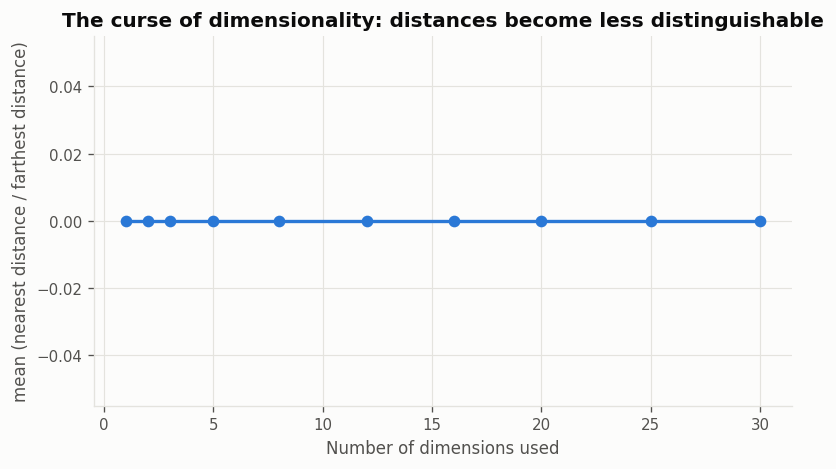

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(dims, ratios, marker="o", color=utils.BLUE)
ax.set_xlabel("Number of dimensions used")
ax.set_ylabel("mean (nearest distance / farthest distance)")
ax.set_title("The curse of dimensionality: distances become less distinguishable")
utils.despine(ax)
utils.save_fig(fig, "02_curse_of_dimensionality.png")
plt.show()

The ratio rises steadily with dimension. In one dimension the nearest point is
far closer than the farthest; by thirty dimensions the two are much more
similar, so "nearest" carries less information. This is the theoretical reason
why k-NN is expected to underperform the tree-based methods on this dataset, and
why feature selection and feature reduction are worth applying.

## 2. Feature selection versus feature reduction

The two are often confused, so it is worth stating the distinction precisely.

- **Feature selection** chooses a *subset* of the original attributes and
  discards the rest. The attributes that survive keep their original meaning.
- **Feature reduction** (or extraction) *transforms* the attributes into a
  smaller set of new ones, each a combination of the originals. Nothing is
  discarded, but the new attributes are no longer the old ones. PCA and LDA are
  reduction techniques.

Both are applied below, and a common baseline model is evaluated on each so that
the approaches can be compared on equal terms.

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, average_precision_score

def baseline_score(Xtr, Xte, label):
    """A fixed decision tree used as a common yardstick for every method."""
    clf = DecisionTreeClassifier(criterion="entropy", max_depth=6,
                                 min_samples_leaf=20, random_state=SEED)
    clf.fit(Xtr, y_train)
    pred = clf.predict(Xte)
    proba = clf.predict_proba(Xte)[:, 1]
    f1 = f1_score(y_test, pred); ap = average_precision_score(y_test, proba)
    n = Xtr.shape[1]
    print(f"{label:<38} features={n:>2}  F1={f1:.4f}  PR-AUC={ap:.4f}")
    return {"method": label, "n_features": int(n), "f1": float(f1), "pr_auc": float(ap)}

comparison = []
comparison.append(baseline_score(X_train, X_test, "All features (baseline)"))

All features (baseline)                features=30  F1=0.8222  PR-AUC=0.8075


## 3. Univariate feature selection

A **univariate** method scores each attribute **on its own**, without reference
to any other attribute, and keeps the highest scoring ones. It is fast and
simple, but because it never looks at combinations it cannot detect that two
attributes are redundant with each other, nor that two weak attributes are
strong together.

Two scoring functions are used:

- **ANOVA F-test** (`f_classif`) - measures how far apart the class means are
  for that attribute, relative to the variance within each class.
- **Mutual information** - measures how much knowing the attribute reduces
  uncertainty about the class. Unlike the F-test it can detect non-linear
  relationships.

In [5]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

f_sel = SelectKBest(score_func=f_classif, k=15).fit(X_train, y_train)
f_scores = pd.Series(f_sel.scores_, index=X_train.columns).sort_values(ascending=False)
print("Top 15 attributes by ANOVA F-test:")
print(f_scores.head(15).round(2))

Top 15 attributes by ANOVA F-test:
V17    22101.46
V14    18463.71
V12    13587.97
V10     8893.46
V16     7665.94
V3      6738.32
V7      6140.52
V11     4474.53
V4      3314.60
V18     2304.04
V1      1808.19
V9      1791.32
V5      1511.58
V2      1376.90
V6       413.50
dtype: float64


In [6]:
mi = mutual_info_classif(X_train, y_train, random_state=SEED)
mi_scores = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)
print("Top 15 attributes by mutual information:")
print(mi_scores.head(15).round(5))

Top 15 attributes by mutual information:
V17    0.00782
V14    0.00765
V10    0.00724
V12    0.00718
V11    0.00630
V16    0.00595
V4     0.00450
V3     0.00449
V18    0.00383
V9     0.00380
V7     0.00373
V2     0.00291
V21    0.00226
V6     0.00206
V27    0.00204
dtype: float64


saved figure -> Results/figures/02_univariate_selection.png


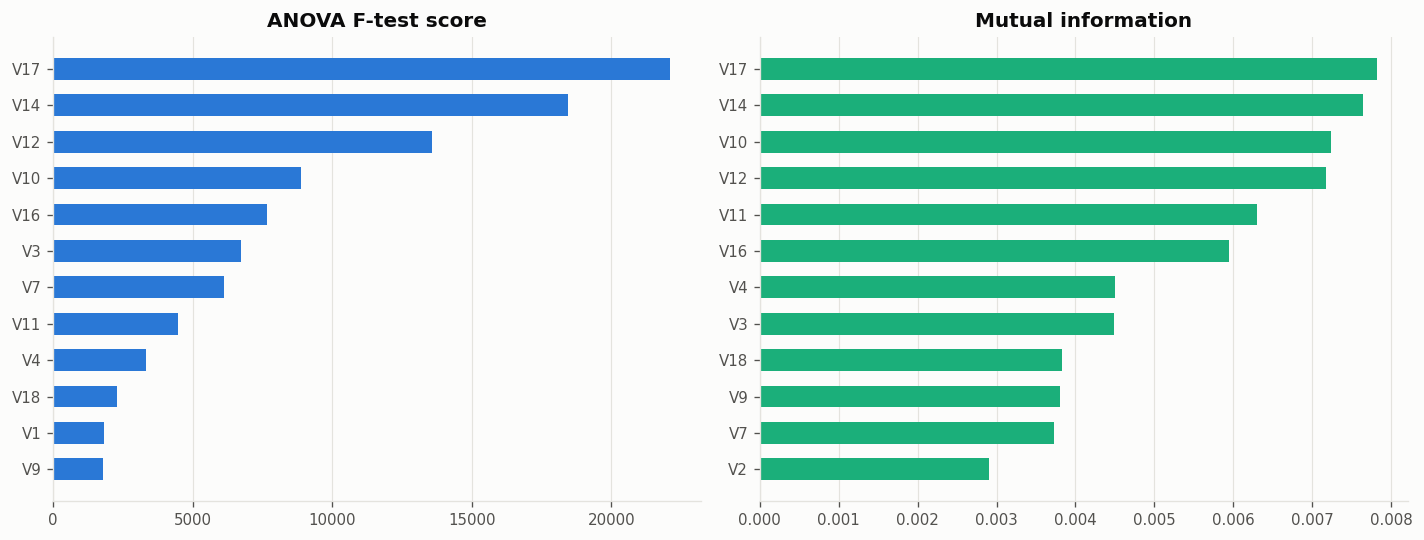

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, s, title, c in zip(axes,
                           [f_scores.head(12), mi_scores.head(12)],
                           ["ANOVA F-test score", "Mutual information"],
                           [utils.BLUE, utils.GREEN]):
    ax.barh(s.index[::-1], s.values[::-1], color=c, height=0.6)
    ax.set_title(title); ax.grid(axis="y", visible=False); utils.despine(ax)
plt.tight_layout()
utils.save_fig(fig, "02_univariate_selection.png")
plt.show()

In [8]:
k = 15
sel_f  = SelectKBest(f_classif, k=k).fit(X_train, y_train)
cols_f = X_train.columns[sel_f.get_support()]
print(f"Selected by F-test (k={k}):", list(cols_f))
comparison.append(baseline_score(X_train[cols_f], X_test[cols_f],
                                 f"Univariate - F-test (k={k})"))

cols_mi = mi_scores.head(k).index
print(f"\nSelected by mutual information (k={k}):", list(cols_mi))
comparison.append(baseline_score(X_train[cols_mi], X_test[cols_mi],
                                 f"Univariate - mutual info (k={k})"))

Selected by F-test (k=15): ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18']


Univariate - F-test (k=15)             features=15  F1=0.7967  PR-AUC=0.8131

Selected by mutual information (k=15): ['V17', 'V14', 'V10', 'V12', 'V11', 'V16', 'V4', 'V3', 'V18', 'V9', 'V7', 'V2', 'V21', 'V6', 'V27']


Univariate - mutual info (k=15)        features=15  F1=0.7967  PR-AUC=0.8188


## 4. Multivariate feature selection

A **multivariate** method evaluates attributes **together**, taking their
interaction into account. **Recursive Feature Elimination (RFE)** is used here:
a model is trained on all attributes, the least important one is removed, and
the process repeats until the desired number remains. Because the model is
retrained at every step, the importance of an attribute is always judged in the
company of the attributes that are still present.

This is more expensive than a univariate filter - it trains the model many times
- but it can keep a pair of attributes that are only useful jointly, and drop
one of two attributes that duplicate each other.

In [9]:
from sklearn.feature_selection import RFE

rfe = RFE(estimator=DecisionTreeClassifier(criterion="entropy", max_depth=6,
                                           random_state=SEED),
          n_features_to_select=15, step=2)
rfe.fit(X_train, y_train)
cols_rfe = X_train.columns[rfe.support_]
print("Selected by RFE (k=15):", list(cols_rfe))
print("\nAttribute elimination ranking (1 = kept):")
print(pd.Series(rfe.ranking_, index=X_train.columns).sort_values().to_string())

Selected by RFE (k=15): ['Time', 'V4', 'V7', 'V8', 'V10', 'V12', 'V13', 'V14', 'V16', 'V17', 'V20', 'V21', 'V26', 'V28', 'Amount']

Attribute elimination ranking (1 = kept):
Time      1
V4        1
V7        1
V14       1
V12       1
V13       1
V10       1
V8        1
V20       1
V26       1
Amount    1
V28       1
V17       1
V21       1
V16       1
V24       2
V27       3
V15       3
V18       4
V25       4
V23       5
V22       5
V11       6
V19       6
V9        7
V6        7
V3        8
V5        8
V2        9
V1        9


In [10]:
comparison.append(baseline_score(X_train[cols_rfe], X_test[cols_rfe],
                                 "Multivariate - RFE (k=15)"))

Multivariate - RFE (k=15)              features=15  F1=0.8222  PR-AUC=0.8002


In [11]:
sets = {"F-test": set(cols_f), "Mutual information": set(cols_mi), "RFE": set(cols_rfe)}
print("Agreement between the three selection methods\n")
for a in sets:
    for b in sets:
        if a < b:
            common = sets[a] & sets[b]
            print(f"{a:<20} vs {b:<20} : {len(common):>2} attributes in common")
print("\nChosen by all three:", sorted(sets['F-test'] & sets['Mutual information'] & sets['RFE']))

Agreement between the three selection methods

F-test               vs Mutual information   : 13 attributes in common
F-test               vs RFE                  :  7 attributes in common
Mutual information   vs RFE                  :  8 attributes in common

Chosen by all three: ['V10', 'V12', 'V14', 'V16', 'V17', 'V4', 'V7']


## 5. Feature selection techniques - the three families

The methods above are examples of the standard taxonomy:

| Family | How it works | Used here |
|---|---|---|
| **Filter** | Scores attributes by a statistical measure, independently of any model. Fast, model-agnostic. | ANOVA F-test, mutual information |
| **Wrapper** | Repeatedly trains a model on candidate subsets and keeps the subset that scores best. Accurate but expensive. | RFE |
| **Embedded** | Selection happens as a side effect of training - the model itself assigns importances. | Decision tree / Random Forest importances (Notebooks 03 and 08) |

In [12]:
emb = DecisionTreeClassifier(criterion="entropy", max_depth=6,
                             min_samples_leaf=20, random_state=SEED).fit(X_train, y_train)
imp = pd.Series(emb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Embedded selection - decision tree importances (top 12):")
print(imp.head(12).round(5))
cols_emb = imp.head(15).index
comparison.append(baseline_score(X_train[cols_emb], X_test[cols_emb],
                                 "Embedded - tree importance (k=15)"))

Embedded selection - decision tree importances (top 12):
V17    0.72225
V14    0.13483
V10    0.03269
V12    0.02724
V26    0.02345
V4     0.02138
V8     0.01220
V28    0.00641
V3     0.00569
V21    0.00388
V19    0.00338
V13    0.00298
dtype: float64


Embedded - tree importance (k=15)      features=15  F1=0.8222  PR-AUC=0.7941


## 6. Feature reduction: Principal Component Analysis

PCA finds a new set of axes - the **principal components** - which are
orthogonal linear combinations of the original attributes, ordered so that the
first captures the greatest possible variance, the second the greatest remaining
variance, and so on. Keeping only the first few components reduces
dimensionality while discarding as little variance as possible.

PCA is **unsupervised**: it never looks at the class label. It maximises
variance, and variance is not the same thing as class separability.

There is an unusual point to make about this dataset. Attributes `V1` to `V28`
**are already principal components** - the publishers applied PCA to the
original transaction attributes before release. So this section applies PCA to
data that has already been through PCA, which is informative in its own right:
the components are already uncorrelated, so a second PCA mainly reorders and
rescales them.

In [13]:
from sklearn.decomposition import PCA

scaler = StandardScaler().fit(X_train)
Xtr_s = scaler.transform(X_train); Xte_s = scaler.transform(X_test)

pca_full = PCA(random_state=SEED).fit(Xtr_s)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
for n in [2, 5, 10, 15, 20, 25, 30]:
    print(f"first {n:>2} components explain {cum[n-1]*100:5.2f}% of the variance")

first  2 components explain 12.31% of the variance
first  5 components explain 22.76% of the variance
first 10 components explain 39.69% of the variance
first 15 components explain 56.47% of the variance
first 20 components explain 73.13% of the variance
first 25 components explain 89.51% of the variance
first 30 components explain 100.00% of the variance


saved figure -> Results/figures/02_pca_variance.png


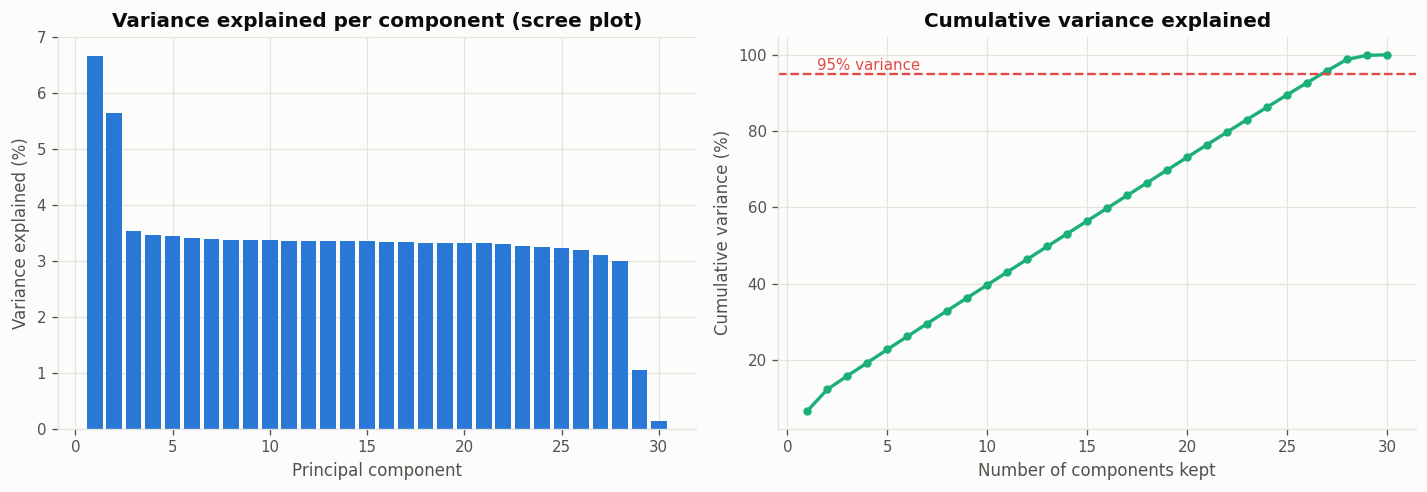

27 components are needed to retain 95% of the variance.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].bar(range(1, len(evr)+1), evr*100, color=utils.BLUE)
axes[0].set_xlabel("Principal component"); axes[0].set_ylabel("Variance explained (%)")
axes[0].set_title("Variance explained per component (scree plot)")
utils.despine(axes[0])

axes[1].plot(range(1, len(cum)+1), cum*100, marker="o", markersize=4, color=utils.GREEN)
axes[1].axhline(95, color=utils.RED, linestyle="--", linewidth=1.4)
axes[1].text(1.5, 96, "95% variance", color=utils.RED, fontsize=9)
axes[1].set_xlabel("Number of components kept"); axes[1].set_ylabel("Cumulative variance (%)")
axes[1].set_title("Cumulative variance explained")
utils.despine(axes[1])
plt.tight_layout()
utils.save_fig(fig, "02_pca_variance.png")
plt.show()

n95 = int(np.argmax(cum >= 0.95) + 1)
print(f"{n95} components are needed to retain 95% of the variance.")

PCA (27 components, 95% var)           features=27  F1=0.7967  PR-AUC=0.7184
saved figure -> Results/figures/02_pca_projection.png


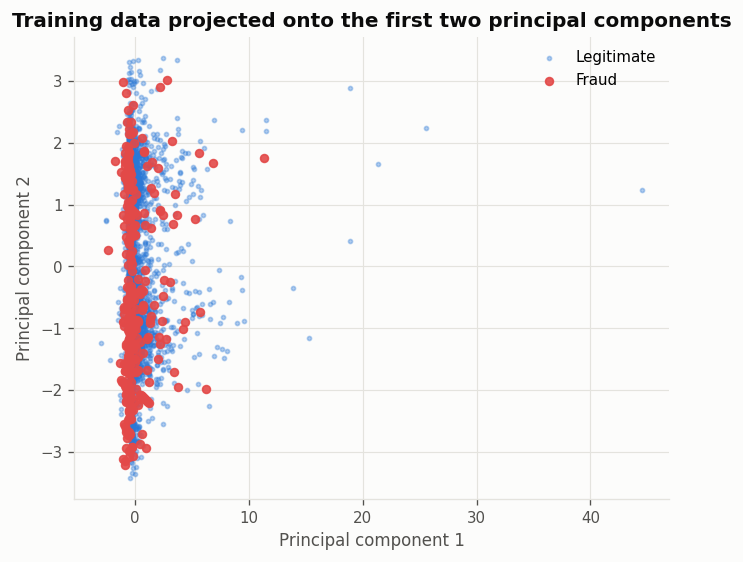

In [15]:
pca = PCA(n_components=n95, random_state=SEED).fit(Xtr_s)
Xtr_pca, Xte_pca = pca.transform(Xtr_s), pca.transform(Xte_s)
comparison.append(baseline_score(Xtr_pca, Xte_pca, f"PCA ({n95} components, 95% var)"))

pca2 = PCA(n_components=2, random_state=SEED).fit(Xtr_s)
P = pca2.transform(Xtr_s)
fig, ax = plt.subplots(figsize=(6.4, 5))
m = np.asarray(y_train) == 0
ax.scatter(P[m, 0][::40], P[m, 1][::40], s=6, color=utils.BLUE, alpha=0.35, label="Legitimate")
ax.scatter(P[~m, 0], P[~m, 1], s=22, color=utils.RED, alpha=0.9, label="Fraud")
ax.set_xlabel("Principal component 1"); ax.set_ylabel("Principal component 2")
ax.set_title("Training data projected onto the first two principal components")
ax.legend(); utils.despine(ax)
utils.save_fig(fig, "02_pca_projection.png")
plt.show()

## 7. Feature reduction: Linear Discriminant Analysis

LDA also produces a lower-dimensional projection, but its objective is the
opposite of PCA's. It is **supervised**: it uses the class labels and seeks the
direction that **maximises the separation between class means while minimising
the scatter within each class**. Where PCA asks "along which axis does the data
vary most?", LDA asks "along which axis are the two classes furthest apart?".

For a two-class problem LDA can produce at most **one** component, because the
number of discriminant directions is bounded by (number of classes - 1).

In [16]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=1).fit(Xtr_s, y_train)
Xtr_lda, Xte_lda = lda.transform(Xtr_s), lda.transform(Xte_s)
print("LDA output shape:", Xtr_lda.shape, "- one component, as expected for 2 classes")
comparison.append(baseline_score(Xtr_lda, Xte_lda, "LDA (1 component)"))

LDA output shape: (198608, 1) - one component, as expected for 2 classes


LDA (1 component)                      features= 1  F1=0.7935  PR-AUC=0.7965


saved figure -> Results/figures/02_lda_projection.png


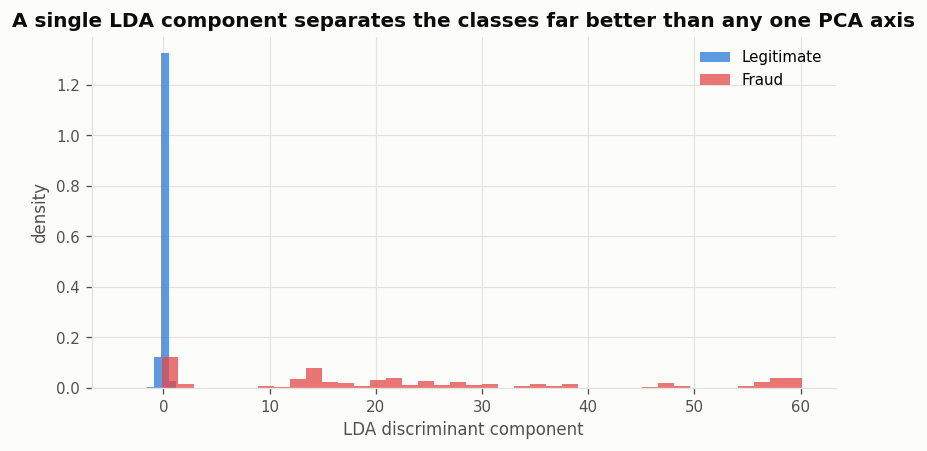

In [17]:
fig, ax = plt.subplots(figsize=(8, 3.8))
m = np.asarray(y_train) == 0
ax.hist(Xtr_lda[m, 0], bins=80, color=utils.BLUE, alpha=0.75, density=True,
        label="Legitimate")
ax.hist(Xtr_lda[~m, 0], bins=40, color=utils.RED, alpha=0.75, density=True,
        label="Fraud")
ax.set_xlabel("LDA discriminant component"); ax.set_ylabel("density")
ax.set_title("A single LDA component separates the classes far better than any one PCA axis")
ax.legend(); utils.despine(ax)
utils.save_fig(fig, "02_lda_projection.png")
plt.show()

The contrast with the PCA scatter plot is striking. Two PCA components leave the
classes heavily overlapped; a single LDA component pushes them into two visibly
distinct humps. This is exactly what the two objectives predict - PCA was never
trying to separate the classes, and LDA was trying to do nothing else.

## 8. Comparison of all approaches

In [18]:
cmp = pd.DataFrame(comparison).sort_values("pr_auc", ascending=False).reset_index(drop=True)
cmp.round(4)

,method,n_features,f1,pr_auc
0,Univariate - mutual info (k=15),15,0.7967,0.8188
1,Univariate - F-test (k=15),15,0.7967,0.8131
2,All features (baseline),30,0.8222,0.8075
3,Multivariate - RFE (k=15),15,0.8222,0.8002
4,LDA (1 component),1,0.7935,0.7965
5,Embedded - tree importance (k=15),15,0.8222,0.7941
6,"PCA (27 components, 95% var)",27,0.7967,0.7184


saved figure -> Results/figures/02_feature_methods_comparison.png


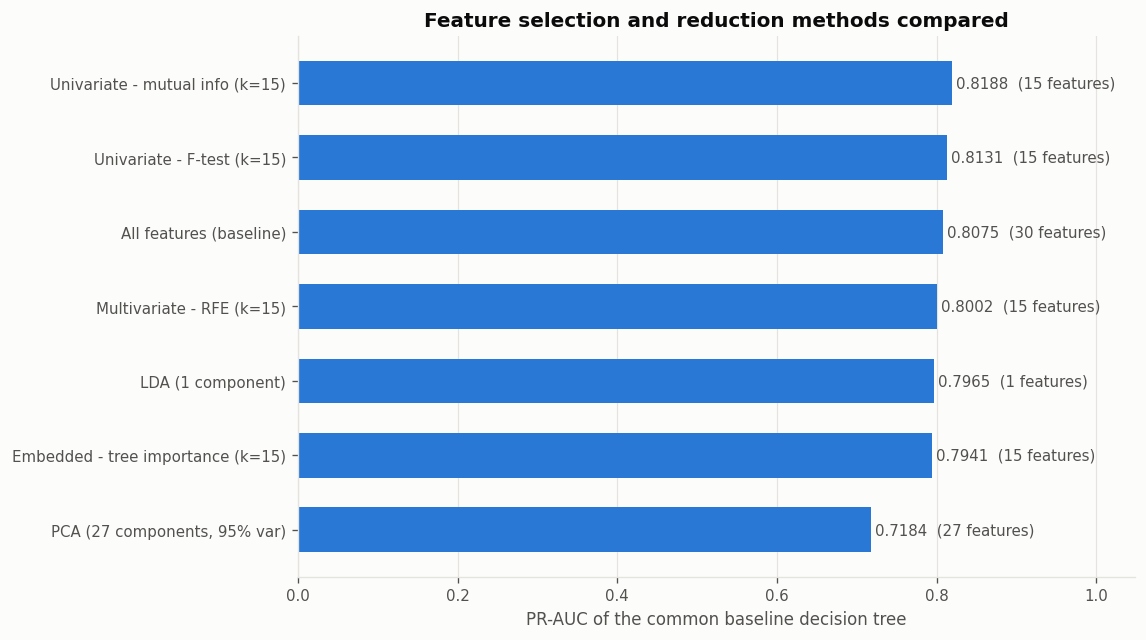

In [19]:
d = cmp.sort_values("pr_auc")
fig, ax = plt.subplots(figsize=(9, 0.55*len(d)+2))
ax.barh(d["method"], d["pr_auc"], color=utils.BLUE, height=0.6)
for i, (v, n) in enumerate(zip(d["pr_auc"], d["n_features"])):
    ax.text(v + 0.005, i, f"{v:.4f}  ({n} features)", va="center", fontsize=9,
            color=utils.INK2)
ax.set_xlim(0, max(d["pr_auc"])*1.28)
ax.set_xlabel("PR-AUC of the common baseline decision tree")
ax.set_title("Feature selection and reduction methods compared")
ax.grid(axis="y", visible=False); utils.despine(ax)
utils.save_fig(fig, "02_feature_methods_comparison.png")
plt.show()

In [20]:
cmp.to_csv(utils.TAB_DIR / "feature_methods_comparison.csv", index=False)
print("saved -> Results/tables/feature_methods_comparison.csv")

saved -> Results/tables/feature_methods_comparison.csv


## 9. Summary and the decision taken for the rest of the project

- The curse of dimensionality was demonstrated empirically: the ratio of nearest
  to farthest neighbour distance rises steadily with dimension, which predicts
  difficulty for k-NN.
- Univariate selection (F-test, mutual information), multivariate selection
  (RFE) and embedded selection (tree importances) broadly agree on which
  attributes matter - `V17`, `V14`, `V12`, `V10`, `V4` appear near the top of
  every ranking.
- PCA needs most of its components to retain 95% of the variance, which is
  expected: the attributes are already principal components and therefore
  already uncorrelated.
- LDA, being supervised, achieves clearly better class separation with a single
  component than PCA does with two.

**Decision.** The remaining notebooks use the **full set of 30 attributes**.
Reducing the feature set did not improve the baseline enough to justify
discarding information, and keeping all attributes makes the comparison between
models in Notebook 10 clean - every model sees exactly the same input. The work
in this notebook stands as the analysis of *whether* reduction helps, which is
the question Unit II asks.